# Tema 4 - Spark SQL y Procesamiento de Datos: Housing

Ejemplo práctico usando el dataset `housing.csv` (open-datasets), con precios de vivienda en California y variables como `median_income`, `median_house_value`, `ocean_proximity`, `total_rooms`, etc.

**Foco del análisis**: ¿cómo varía el valor medio de la vivienda según la proximidad al océano y la renta media de la zona?

Contenido:
1. Fundamentos de Spark SQL (vistas temporales + SQL nativo)
2. Operaciones con DataFrames (select, filter, groupBy)
3. Funciones integradas para tratamiento de nulos
4. LAB: agregación, función de ventana y visualización (EDA)

In [1]:
import os
from pyspark.sql import SparkSession
import pyspark.sql.functions as F

# Requiere winutils.exe en HADOOP_HOME\bin (necesario en Windows)
os.environ["HADOOP_HOME"] = r"C:\hadoop\winutils\hadoop-3.3.6"
os.environ["hadoop.home.dir"] = os.environ["HADOOP_HOME"]
os.environ["PATH"] = os.path.join(os.environ["HADOOP_HOME"], "bin") + ";" + os.environ["PATH"]

# Reinicia el kernel antes de ejecutar esta celda si vienes de otro notebook con Spark ya iniciado
spark = SparkSession.builder.appName("EDA_Housing").getOrCreate()

In [2]:
csv_path = "./open-datasets/housing.csv"
df_housing = spark.read.csv(csv_path, header=True, inferSchema=True)

df_housing.printSchema()
df_housing.show(5)

root
 |-- longitude: double (nullable = true)
 |-- latitude: double (nullable = true)
 |-- housing_median_age: double (nullable = true)
 |-- total_rooms: double (nullable = true)
 |-- total_bedrooms: double (nullable = true)
 |-- population: double (nullable = true)
 |-- households: double (nullable = true)
 |-- median_income: double (nullable = true)
 |-- median_house_value: double (nullable = true)
 |-- ocean_proximity: string (nullable = true)

+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+
|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|ocean_proximity|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+
|  -122.23|   37.88|              41.0|      880.0|         129.0|     322.0|     126.0|       8.3252|          452600.0|       NEAR B

## 1. Fundamentos de Spark SQL

Registramos el DataFrame como vista temporal para consultarlo con SQL nativo.

In [3]:
df_housing.createOrReplaceTempView("viviendas")

spark.sql("""
    SELECT
        COUNT(*) AS total_filas,
        ROUND(AVG(median_house_value), 2) AS valor_medio,
        ROUND(AVG(median_income), 2) AS renta_media
    FROM viviendas
""").show()

+-----------+-----------+-----------+
|total_filas|valor_medio|renta_media|
+-----------+-----------+-----------+
|      20640|  206855.82|       3.87|
+-----------+-----------+-----------+



## 2. Operaciones con DataFrames

Selección/derivación de columnas, filtrado y agrupación usando la DataFrame API.

In [4]:
# Derivamos el ratio habitaciones/población (proxy de densidad de vivienda)
df_derivado = df_housing.select(
    F.col("median_income"), F.col("median_house_value"),
    F.col("population"), F.col("total_rooms"), F.col("ocean_proximity")
).withColumn(
    "habitaciones_por_habitante",
    F.round(F.col("total_rooms") / F.col("population"), 2)
)
df_derivado.show(10)

+-------------+------------------+----------+-----------+---------------+--------------------------+
|median_income|median_house_value|population|total_rooms|ocean_proximity|habitaciones_por_habitante|
+-------------+------------------+----------+-----------+---------------+--------------------------+
|       8.3252|          452600.0|     322.0|      880.0|       NEAR BAY|                      2.73|
|       8.3014|          358500.0|    2401.0|     7099.0|       NEAR BAY|                      2.96|
|       7.2574|          352100.0|     496.0|     1467.0|       NEAR BAY|                      2.96|
|       5.6431|          341300.0|     558.0|     1274.0|       NEAR BAY|                      2.28|
|       3.8462|          342200.0|     565.0|     1627.0|       NEAR BAY|                      2.88|
|       4.0368|          269700.0|     413.0|      919.0|       NEAR BAY|                      2.23|
|       3.6591|          299200.0|    1094.0|     2535.0|       NEAR BAY|                  

In [5]:
# Filtrado: viviendas con renta media (median_income, en decenas de miles $) superior a 5
df_filtrado = df_derivado.filter(F.col("median_income") > 5)
print(f"Filas tras filtrar median_income > 5: {df_filtrado.count()}")
df_filtrado.show(5)

Filas tras filtrar median_income > 5: 4489
+-------------+------------------+----------+-----------+---------------+--------------------------+
|median_income|median_house_value|population|total_rooms|ocean_proximity|habitaciones_por_habitante|
+-------------+------------------+----------+-----------+---------------+--------------------------+
|       8.3252|          452600.0|     322.0|      880.0|       NEAR BAY|                      2.73|
|       8.3014|          358500.0|    2401.0|     7099.0|       NEAR BAY|                      2.96|
|       7.2574|          352100.0|     496.0|     1467.0|       NEAR BAY|                      2.96|
|       5.6431|          341300.0|     558.0|     1274.0|       NEAR BAY|                      2.28|
|       6.1183|           75000.0|      86.0|      135.0|       NEAR BAY|                      1.57|
+-------------+------------------+----------+-----------+---------------+--------------------------+
only showing top 5 rows


In [6]:
# Agrupación: valor medio de vivienda y renta media por proximidad al océano
df_agrupado = df_housing.groupBy("ocean_proximity").agg(
    F.round(F.avg("median_house_value"), 2).alias("valor_medio_vivienda"),
    F.round(F.avg("median_income"), 2).alias("renta_media"),
    F.count("*").alias("num_viviendas")
)
df_agrupado.orderBy(F.desc("valor_medio_vivienda")).show()

+---------------+--------------------+-----------+-------------+
|ocean_proximity|valor_medio_vivienda|renta_media|num_viviendas|
+---------------+--------------------+-----------+-------------+
|         ISLAND|            380440.0|       2.74|            5|
|       NEAR BAY|           259212.31|       4.17|         2290|
|     NEAR OCEAN|           249433.98|       4.01|         2658|
|      <1H OCEAN|           240084.29|       4.23|         9136|
|         INLAND|           124805.39|       3.21|         6551|
+---------------+--------------------+-----------+-------------+



## 3. Funciones integradas: tratamiento de valores nulos

`total_bedrooms` contiene valores nulos en este dataset.

In [7]:
# Conteo de nulos por columna antes de limpiar
df_housing.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df_housing.columns
]).show()

+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+
|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|ocean_proximity|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+
|        0|       0|                 0|          0|           207|         0|         0|            0|                 0|              0|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+



In [8]:
# Limpieza: rellenamos total_bedrooms nulo con la mediana de la propia columna
mediana_bedrooms = df_housing.approxQuantile("total_bedrooms", [0.5], 0.01)[0]

df_clean = df_housing.fillna({"total_bedrooms": mediana_bedrooms})

df_clean.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df_clean.columns
]).show()

+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+
|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|ocean_proximity|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+
|        0|       0|                 0|          0|             0|         0|         0|            0|                 0|              0|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+



## 4. LAB: Análisis Exploratorio (EDA) y visualización final

**Tendencia a estudiar**: relación entre la renta media de la zona (`median_income`) y el valor medio de la vivienda (`median_house_value`), agrupando por tramos de renta.

In [9]:
# Creamos tramos de renta (bucketing) y agregamos el valor medio de vivienda por tramo
df_tramos = df_clean.withColumn(
    "tramo_renta",
    F.when(F.col("median_income") < 2, "< 2")
     .when(F.col("median_income") < 4, "2-4")
     .when(F.col("median_income") < 6, "4-6")
     .when(F.col("median_income") < 8, "6-8")
     .otherwise("8+")
).withColumn(
    # Orden numérico auxiliar: orderBy sobre texto pondría "< 2" al final (alfabéticamente)
    "orden_tramo",
    F.when(F.col("median_income") < 2, 1)
     .when(F.col("median_income") < 4, 2)
     .when(F.col("median_income") < 6, 3)
     .when(F.col("median_income") < 8, 4)
     .otherwise(5)
)

df_resumen = df_tramos.groupBy("tramo_renta", "orden_tramo").agg(
    F.round(F.avg("median_house_value"), 2).alias("valor_medio_vivienda"),
    F.count("*").alias("num_viviendas")
).orderBy("orden_tramo").drop("orden_tramo")

df_resumen.show()

+-----------+--------------------+-------------+
|tramo_renta|valor_medio_vivienda|num_viviendas|
+-----------+--------------------+-------------+
|        < 2|           112512.67|         2439|
|        2-4|           167921.04|        10077|
|        4-6|           244385.44|         5751|
|        6-8|           344452.15|         1682|
|         8+|           460370.68|          691|
+-----------+--------------------+-------------+



### Agregaciones avanzadas: función de ventana

Usando `Window.partitionBy`, obtenemos, dentro de cada zona (`ocean_proximity`), las 3 viviendas con mayor valor.

In [10]:
from pyspark.sql.window import Window

# Ventana: partición independiente por cada zona, ordenada por valor de vivienda descendente
window_spec = Window.partitionBy("ocean_proximity").orderBy(F.desc("median_house_value"))

df_top3_por_zona = df_tramos.withColumn(
    "ranking", F.rank().over(window_spec)
).filter(F.col("ranking") <= 3)

df_top3_por_zona.select(
    "ocean_proximity", "ranking", "median_income", "median_house_value"
).orderBy("ocean_proximity", "ranking").show(20)

+---------------+-------+-------------+------------------+
|ocean_proximity|ranking|median_income|median_house_value|
+---------------+-------+-------------+------------------+
|      <1H OCEAN|      1|        2.975|          500001.0|
|      <1H OCEAN|      1|        5.128|          500001.0|
|      <1H OCEAN|      1|       3.8088|          500001.0|
|      <1H OCEAN|      1|       1.6393|          500001.0|
|      <1H OCEAN|      1|       3.0179|          500001.0|
|      <1H OCEAN|      1|       3.5573|          500001.0|
|      <1H OCEAN|      1|      10.2849|          500001.0|
|      <1H OCEAN|      1|       7.0516|          500001.0|
|      <1H OCEAN|      1|      11.2185|          500001.0|
|      <1H OCEAN|      1|      15.0001|          500001.0|
|      <1H OCEAN|      1|      15.0001|          500001.0|
|      <1H OCEAN|      1|       8.2934|          500001.0|
|      <1H OCEAN|      1|       8.9616|          500001.0|
|      <1H OCEAN|      1|      15.0001|          500001.

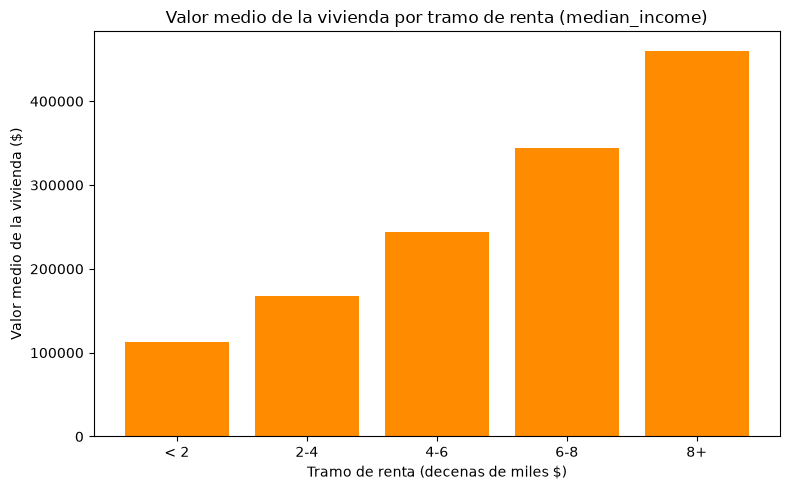

In [11]:
import matplotlib.pyplot as plt

# Convertimos el resultado ya agregado (pocas filas) a pandas para graficarlo
pdf_resumen = df_resumen.toPandas()

plt.figure(figsize=(8, 5))
plt.bar(pdf_resumen["tramo_renta"], pdf_resumen["valor_medio_vivienda"], color="darkorange")
plt.title("Valor medio de la vivienda por tramo de renta (median_income)")
plt.xlabel("Tramo de renta (decenas de miles $)")
plt.ylabel("Valor medio de la vivienda ($)")
plt.tight_layout()
plt.show()